# AF2Rank for Protein Interactions

This [code](https://github.com/sahinmtaylan/af2rank-pipeline) is based on the previous work of **Roney and  Ovchinnikov (2022)**: https://doi.org/10.1103/PhysRevLett.129.238101

This modified AF2Rank pipeline scores protein dimers on a Colab GPU by using AF2-ptm (weight 2).

You can directly run the bundled 1BRS example or upload your own input to score your own target.

Run the sections in order.


## Setup

Run this section once per Colab session. It prepares inference and downloads the required AlphaFold2-ptm weight-2 (about 373 MB on the first run).


In [ ]:
#@title 1. Initialize GPU { display-mode: "form" }
REPOSITORY_URL = "https://github.com/sahinmtaylan/af2rank-pipeline.git"

from pathlib import Path
import importlib.util
import os
import shutil
import subprocess
import sys

workspace = Path("/content") if Path("/content").is_dir() else Path.cwd()
possible_repos = [workspace / "af2rank-pipeline", workspace]
possible_repos += [p.parent for p in workspace.glob("*/pyproject.toml")]
possible_repos += [p.parent for p in workspace.glob("*/*/pyproject.toml")]
repo = next((p for p in possible_repos
             if (p / "pyproject.toml").is_file()
             and (p / "uv.lock").is_file()
             and (p / "examples/1brs/model.pdb").is_file()), None)
if repo is None:
    repo = workspace / "af2rank-pipeline"
    subprocess.run(["git", "clone", "--depth", "1", REPOSITORY_URL, str(repo)], check=True)
repo = repo.resolve()

import jax
if not any(device.platform == "gpu" for device in jax.devices()):
    raise RuntimeError("JAX cannot see a GPU. In Colab, select Runtime → Change runtime type → GPU.")
print("Project:", repo)
print("Colab JAX:", jax.__version__, "·", jax.devices())


In [ ]:
#@title 2. Prepare inference environment { display-mode: "form" }
# The repository's tested inference stack pins JAX 0.4.20 and Python 3.10.
# Current Colab images can provide a newer JAX; reuse the host CUDA driver
# while keeping these pinned Python packages in a cached project environment.
pipeline_env = {**os.environ, "MPLBACKEND": "Agg"}
pipeline_python = repo / ".venv/bin/python"
pipeline_cli = repo / ".venv/bin/af2rank-pipeline"

def check_inference_environment():
    return subprocess.run([
        str(pipeline_python), "-c",
        "import sys, jax, colabdesign; print('Python:', sys.version.split()[0]); "
        "print('JAX:', jax.__version__, 'devices:', jax.devices()); "
        "assert any(d.platform == 'gpu' for d in jax.devices()), 'JAX does not see a GPU'",
    ], capture_output=True, text=True, cwd=repo, env=pipeline_env)

probe = (check_inference_environment()
         if pipeline_python.is_file() and pipeline_cli.is_file() else None)
if probe is None or probe.returncode:
    if shutil.which("uv") is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv==0.12.20"], check=True)
    uv = shutil.which("uv")
    if uv is None:
        raise RuntimeError("uv was installed but is not on PATH")
    subprocess.run([uv, "python", "install", "3.10"], check=True, cwd=repo)
    subprocess.run([uv, "sync", "--locked", "--extra", "inference", "--extra", "dockq"], check=True, cwd=repo)
    subprocess.run([
        uv, "pip", "install", "--python", str(pipeline_python),
        "--constraint", str(repo / "env/cuda12-constraints.txt"),
        "--find-links", "https://storage.googleapis.com/jax-releases/jax_cuda_releases.html",
        "jax[cuda12_pip]==0.4.20",
    ], check=True, cwd=repo)
    probe = check_inference_environment()
if probe.returncode:
    raise RuntimeError(f"Inference setup failed:\n{probe.stdout}{probe.stderr}")
print(probe.stdout.strip())

# These packages render results in the Colab kernel; they do not change the
# private inference environment or Colab's preinstalled JAX/CUDA stack.
viewer_packages = {
    "py3Dmol": "py3Dmol==2.5.5",
    "ipywidgets": "ipywidgets>=8,<9",
    "pandas": "pandas>=2,<4",
    "matplotlib": "matplotlib>=3.8,<4",
}
missing = [pin for module, pin in viewer_packages.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
    importlib.invalidate_caches()
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass
print("Inference and result viewer ready")


In [ ]:
#@title 3. Download model weight { display-mode: "form" }
params = workspace / "af2rank-weights" / "params"
subprocess.run([sys.executable, str(repo / "env/download_default_params.py"), str(params)],
               check=True, cwd=repo)
model_weight = params / "params_model_2_ptm.npz"
print("Model weight ready:", model_weight.name)


In [ ]:
#@title 4. Prepare notebook helpers { display-mode: "form" }
import csv
import gzip
import html
import json
import re
import signal
import tempfile
from datetime import datetime, timezone

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import py3Dmol
from IPython.display import HTML, clear_output, display

def prepare_model_directory(fasta, model_paths):
    """Validate files and collect the selected models in a fresh directory."""
    if not model_paths:
        raise ValueError("Select at least one model file")
    for path in [fasta, *model_paths]:
        if not path.is_file() or path.stat().st_size == 0:
            raise FileNotFoundError(f"Selected input is missing or empty: {path}. Upload it again.")

    input_dir = Path(tempfile.mkdtemp(prefix="af2rank-input-", dir=workspace))
    models = input_dir / "models"
    models.mkdir()
    for path in model_paths:
        destination = models / path.name
        if destination.exists():
            raise ValueError(f"Duplicate model filename: {path.name}")
        shutil.copyfile(path, destination)

    return models

def run_with_progress(command, target, model_count, run_out):
    """Run the command with progress, logging, and result checks."""
    progress = widgets.IntProgress(value=0, max=model_count, description="AF2Rank:",
                                   bar_style="info", layout=widgets.Layout(width="100%"))
    run_status = widgets.HTML("<b>Preparing and cleaning inputs…</b>")
    run_log = widgets.Output()
    log_panel = widgets.Accordion(children=[run_log], selected_index=None)
    log_panel.set_title(0, "Run log")
    display(widgets.VBox([run_status, progress, log_panel]))
    log_path = run_out / "logs/notebook.log"
    log_path.parent.mkdir(parents=True, exist_ok=True)
    # Unbuffered output also applies to the inference subprocess launched by the CLI.
    process = None
    started_models = 0
    failure_message = None
    last_log_message = ""
    try:
        process = subprocess.Popen(
            command, cwd=repo, env={**pipeline_env, "PYTHONUNBUFFERED": "1"},
            stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1,
            start_new_session=True,
        )
        with log_path.open("w") as log:
            for line in process.stdout:
                log.write(line)
                log.flush()
                with run_log:
                    print(line, end="")
                message = line.strip()
                if message:
                    last_log_message = message
                if message.startswith("af2rank-pipeline: error: "):
                    failure_message = message.removeprefix("af2rank-pipeline: error: ")
                cleaned = re.fullmatch(r"cleaned (\d+) model\(s\)", message)
                if cleaned:
                    # Multi-model PDBs can contain more models than uploaded files.
                    progress.max = int(cleaned.group(1))
                    run_status.value = f"<b>Loading AF2Rank · {progress.max} model(s)</b>"
                elif message.startswith(f"[{target}] scoring "):
                    name = message[len(f"[{target}] scoring "):].rsplit(" with ", 1)[0]
                    # Starting the next model means the preceding one finished.
                    progress.value = started_models
                    started_models += 1
                    run_status.value = (
                        f"<b>{progress.value}/{progress.max} completed</b> · "
                        f"Scoring {started_models}/{progress.max}: {html.escape(name)}")
                elif re.fullmatch(r"af2rank completed \d+ model\(s\)", message):
                    progress.value = progress.max
                    run_status.value = "<b>AF2Rank complete · Computing interface metrics…</b>"
        returncode = process.wait()
        if returncode:
            raise RuntimeError(
                failure_message or f"Pipeline exited with status {returncode}: {last_log_message or 'No error output'}. See the run log: {log_path}"
            )

        # Verify that the results cover every discovered input, including multi-model PDBs.
        with (run_out / "manifests/raw_models.csv").open() as handle:
            raw_rows = list(csv.DictReader(handle))
        with (run_out / "manifests/final_models.csv").open() as handle:
            final_rows = list(csv.DictReader(handle))
        if len(raw_rows) < model_count or not final_rows or (
            len(final_rows) != len(raw_rows)
            or {row["model_id"] for row in final_rows} != {row["model_id"] for row in raw_rows}
        ):
            raise RuntimeError(f"Incomplete results in {run_out}; inspect the run output")
        progress.value = progress.max
        progress.bar_style = "success"
        run_status.value = f"<b>Done · {len(final_rows)} model(s) scored</b>"
    except BaseException as exc:
        # Stop the whole process group, including GPU inference, on interruption.
        if process is not None and process.poll() is None:
            os.killpg(process.pid, signal.SIGTERM)
            try:
                process.wait(timeout=10)
            except subprocess.TimeoutExpired:
                os.killpg(process.pid, signal.SIGKILL)
                process.wait()
        progress.bar_style = "danger"
        run_status.value = (
            "<b>Run interrupted</b>" if isinstance(exc, KeyboardInterrupt)
            else f"<b>Run failed</b><br>{html.escape(str(exc))}<br><small>Full details are in the log below.</small>"
        )
        log_panel.selected_index = 0
        raise
    finally:
        if process is not None:
            process.stdout.close()
    return run_out

def result_path(value, out):
    path = Path(str(value))
    if path.is_file():
        return path
    # The CSV records the original absolute path; resolve it after moving a run.
    parts = path.parts
    if out.name in parts:
        return out.joinpath(*parts[parts.index(out.name) + 1:])
    for directory in ("cleaned", "af2rank", "additional_metrics", "manifests"):
        if directory in parts:
            return out.joinpath(*parts[parts.index(directory):])
    return out / path

def draw_structures(row, out):
    chain_colors = ["#0f9d8a", "#e5a83b", "#8068c5", "#d96d62", "#3b88bd"]
    display(HTML("<b>Left:</b> cleaned input · chain colors &nbsp;&nbsp; "
                 "<b>Right:</b> AF2Rank output · pLDDT colors"))
    paths = [result_path(row[name], out) for name in ("input_pdb", "output_pdb")]
    if not all(path.is_file() for path in paths):
        print("Missing structure:", *paths, sep="\n")
        return
    view = py3Dmol.view(width=900, height=420, viewergrid=(1, 2))
    for panel, path in enumerate(paths):
        position = (0, panel)
        pdb_text = path.read_text()
        view.addModel(pdb_text, "pdb", viewer=position)
        if panel == 1:
            view.setStyle({"cartoon": {"colorscheme": {
                "prop": "b", "gradient": "roygb", "min": 50, "max": 90,
            }}}, viewer=position)
        else:
            view.setStyle({"cartoon": {"color": "#9ca3af"}}, viewer=position)
            chains = list(dict.fromkeys(line[21] for line in pdb_text.splitlines()
                                        if line.startswith("ATOM") and len(line) > 21))
            for chain, color in zip(chains, chain_colors):
                view.setStyle({"chain": chain}, {"cartoon": {"color": color}}, viewer=position)
        view.zoomTo(viewer=position)
    view.show()


def draw_pae(row, out, target_spec):
    chain_lengths = [item["length"] for item in target_spec["chains"]]
    path = result_path(row["pae_json"], out)
    with gzip.open(path, "rt") as source:
        matrix = np.asarray(json.load(source)["pae"])
    fig, ax = plt.subplots(figsize=(6.4, 5.4))
    image = ax.imshow(matrix, cmap="magma_r", vmin=0, vmax=30,
                      origin="upper", interpolation="nearest")
    boundaries = np.cumsum(chain_lengths)[:-1]
    for boundary in boundaries:
        ax.axhline(boundary - 0.5, color="white", lw=1)
        ax.axvline(boundary - 0.5, color="white", lw=1)
    ticks = [sum(chain_lengths[:i]) + length / 2 - 0.5
             for i, length in enumerate(chain_lengths)]
    labels = [item["canonical_id"] for item in target_spec["chains"]]
    ax.set_xticks(ticks, labels)
    ax.set_yticks(ticks, labels)
    ax.set_xlabel("Residue / chain")
    ax.set_ylabel("Residue / chain")
    ax.set_title(f"PAE · {row['model_id']}")
    fig.colorbar(image, ax=ax, label="Predicted aligned error (Å)")
    fig.tight_layout()
    display(fig)
    plt.close(fig)


def show_details(row, results, dockq_table, pae_table):
    metric_names = {
        "plddt": "Mean pLDDT", "ptm": "pTM", "i_ptm": "Interface pTM",
        "actifptm": "actifpTM", "actifptm_prob": "actifpTM probability",
        "actifptm_binary": "actifpTM binary", "pae": "Mean PAE (Å)",
        "tm_i": "TM-score input", "tm_o": "TM-score output",
        "tm_io": "TM-score input→output", "composite": "Composite score",
        "pae_contacts_mean": "Contact PAE mean (Å)",
        "pae_contacts_min": "Contact PAE min (Å)",
        "pae_contacts_max": "Contact PAE max (Å)",
        "pae_contacts_count": "PAE contacts", "missing_residue_count": "Missing residues",
        "skipped_mismatch_count": "Skipped mismatches",
    }
    model_id = str(row["model_id"])
    per_chain = [name for name in results.columns
                 if name.startswith(("chain_ptm_", "actifptm_", "iptm_"))
                 and name not in ("actifptm_prob", "actifptm_binary")]
    names = [name for name in (*metric_names, *per_chain) if name in results.columns]
    values = pd.DataFrame({"Metric": [metric_names.get(name, name) for name in names],
                           "Value": [row[name] for name in names]})
    values = values[values["Value"].notna() & (values["Value"].astype(str) != "N/A")]
    display(HTML("<h4>Confidence and AF2Rank scores</h4>"))
    display(values.reset_index(drop=True))
    matches = dockq_table["model_id"].astype(str) == model_id
    if "run_name" in dockq_table:
        matches |= dockq_table["run_name"].astype(str) == model_id
    interface_rows = dockq_table[matches]
    dockq_columns = [name for name in
                     ("interface", "DockQ", "F1", "iRMSD", "LRMSD", "fnat", "clashes")
                     if name in interface_rows.columns]
    display(HTML("<h4>Input–output interface comparison</h4>"))
    display(interface_rows[dockq_columns].round(3).reset_index(drop=True))
    directional = pae_table[pae_table["model_id"].astype(str) == model_id]
    pae_columns = [name for name in
                   ("interface", "direction", "pae_count", "pae_mean", "pae_min", "pae_max")
                   if name in directional.columns]
    display(HTML("<h4>Directional interface PAE</h4>"))
    display(directional[pae_columns].round(3).reset_index(drop=True))


## Input

The pipeline needs two inputs:

**1-** Concatanated FASTA information for the dimer, as in the following:

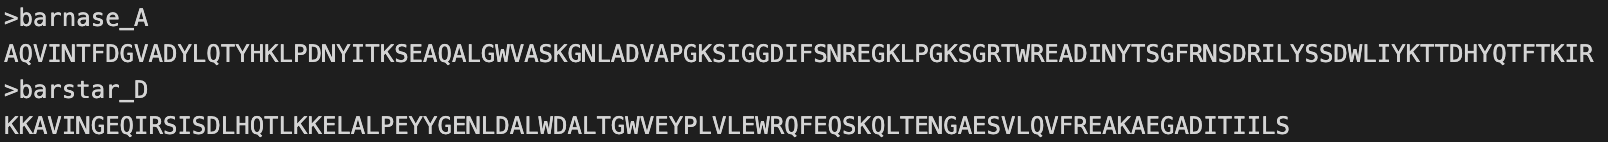

**2-** Corresponding coordinate file (pdb or mmCIF).

For the example run, we pre-uploaded the 1BRS dimer FASTA and its corresponding coordinate file. Either use these files by running the following cell or replace the **FASTA and coordinate files** to try your own model.

In the model section, the upload of **ensembles** is also allowed.

In [ ]:
# Choose FASTA and model files
from google.colab import files as colab_files

# Clear the previous selection until both upload steps finish.
input_selection = None
out = None
upload_dir = Path(tempfile.mkdtemp(prefix="af2rank-upload-", dir=workspace))

def pick_input_files(kind, allowed, limit=None):
    # The native Colab uploader waits until every selected file reaches Python.
    received = colab_files.upload(target_dir=str(upload_dir / kind.lower()))
    paths = [Path(name) for name in received]
    if limit is not None and len(paths) > limit:
        raise ValueError(f"Select at most {limit} {kind} file(s). Rerun this cell.")
    for path in paths:
        if not path.name.lower().endswith(allowed):
            raise ValueError(f"Unsupported {kind} file: {path.name}. Rerun this cell.")
        if not path.is_file() or path.stat().st_size == 0:
            raise ValueError(f"Upload is missing or empty: {path.name}. Rerun this cell.")
    return paths

display(HTML("<b>1. Target FASTA</b><br>Select one FASTA, "
             "or click <b>Cancel upload</b> to use the bundled 1BRS FASTA."))
fastas = pick_input_files("FASTA", (".fa", ".fasta", ".faa"), 1)
fasta = fastas[0] if fastas else repo / "examples/1brs/target.fasta"
fasta_label = fasta.name if fastas else "bundled 1BRS FASTA"
display(HTML(f"<b>FASTA selected:</b> {html.escape(fasta_label)}"))

model_hint = ("Upload the models matching your FASTA." if fastas else
              "Or click <b>Cancel upload</b> to use the bundled 1BRS model.")
display(HTML(f"<b>2. Model files</b><br>Select your model files together. {model_hint}"))
model_paths = pick_input_files("models", (".pdb", ".pdb.gz", ".cif", ".mmcif"))
if fastas and not model_paths:
    raise ValueError("A custom FASTA needs matching model files. Rerun this cell and upload both separately.")
model_paths = model_paths or [repo / "examples/1brs/model.pdb"]
target = (re.sub(r"[^A-Za-z0-9_-]+", "_", fasta.stem).strip("_-") or "target") if fastas else "1brs"
input_selection = {"fasta": fasta, "models": tuple(model_paths), "target": target}

clear_output()
model_labels = "".join(
    f"<li>{html.escape(path.name)} ({path.stat().st_size:,} bytes)</li>"
    for path in model_paths)
display(HTML(
    "<div style='padding:12px;background:#eef6f5;border-radius:8px'>"
    f"<b>Ready · {len(model_paths)} model file(s) · target: {html.escape(target)}</b>"
    f"<br>FASTA: {html.escape(fasta_label)}"
    f"<br>Models:<ul style='margin:4px 0'>{model_labels}</ul></div>"))


## Run


In [ ]:
# Score models
out = None
if globals().get("input_selection") is None:
    raise RuntimeError("Complete Choose FASTA and model files and wait for Ready before scoring")

target = input_selection["target"]
fasta = input_selection["fasta"]
model_paths = list(input_selection["models"])
models = prepare_model_directory(fasta, model_paths)

stamp = datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S-%f")
run_out = workspace / "af2rank-results" / f"{target}-{stamp}"
command = [
    str(pipeline_cli), "run-target",
    "--target", target,
    "--fasta", str(fasta),
    "--models", str(models),
    "--out", str(run_out),
    "--params", str(params),
    "--workers", "1",
    "--strict-clean",
]
out = run_with_progress(command, target=target,
                        model_count=len(model_paths), run_out=run_out)


## Results


In [ ]:
# Score overview

if not isinstance(globals().get("out"), Path):
    raise RuntimeError("Run Score models successfully for the current selection first")

final_csv = out / "manifests/final_models.csv"
if not final_csv.is_file():
    raise FileNotFoundError(f"Results table not found: {final_csv}")
results = pd.read_csv(final_csv)
if results.empty:
    raise RuntimeError("No models were scored; inspect the run output")

display(HTML(f"<b>{len(results)} model(s) scored · {html.escape(target)}</b>"))

overview_columns = {
    "model_id": "Model", "plddt": "pLDDT", "ptm": "pTM",
    "i_ptm": "interface pTM", "actifptm": "actifpTM",
    "dockq_io": "DockQ input→output", "pae_contacts_mean": "Contact PAE (Å)",
}
overview = results[[key for key in overview_columns if key in results.columns]].rename(
    columns=overview_columns).copy()
for name in overview.columns:
    if name != "Model":
        overview[name] = pd.to_numeric(overview[name], errors="coerce").round(3)
display(overview)
display(HTML("<small>DockQ compares the cleaned input with AF2Rank's output; "
             "it is not accuracy against an experimental structure. "
             "The ZIP includes every metric and structure.</small>"))


In [ ]:
# Inspect the AF2Rank-rescored model
from google.colab import widgets as colab_widgets

if not isinstance(globals().get("out"), Path):
    raise RuntimeError("Run Score models successfully for the current selection first")
results = pd.read_csv(out / "manifests/final_models.csv", dtype={"model_id": str})
if results.empty:
    raise RuntimeError("No models were scored; inspect the run output")
dockq_table = pd.read_csv(out / "additional_metrics/dockq_metrics.csv", dtype={"model_id": str})
pae_table = pd.read_csv(out / "additional_metrics/pae_summary.csv", dtype={"model_id": str})
target_spec = json.loads((out / "target_spec.json").read_text())

if "model_picker" in globals():
    model_picker.close()
model_picker = widgets.Dropdown(
    options=[(str(row["model_id"]), i) for i, row in results.iterrows()],
    description="Model:", layout=widgets.Layout(width="min(100%, 600px)"))

def refresh_model_views(change=None):
    row = results.iloc[model_picker.value]
    for title, render in (
        ("Structures", lambda: draw_structures(row, out)),
        ("PAE", lambda: draw_pae(row, out, target_spec)),
        ("Detailed metrics", lambda: show_details(row, results, dockq_table, pae_table)),
    ):
        with model_tabs.output_to(title, select=False):
            model_tabs.clear_tab()
            try:
                render()
            except Exception as exc:
                display(HTML(f"<p style='color:#b91c1c'><b>{html.escape(title)} error:</b> "
                             f"{html.escape(str(exc))}</p>"))

# Colab's native tabs support HTML/JavaScript viewers and ordinary rich output.
display(model_picker)
model_tabs = colab_widgets.TabBar(["Structures", "PAE", "Detailed metrics"])
model_picker.observe(refresh_model_views, names="value")
refresh_model_views()


In [ ]:
# Download complete results
archive = shutil.make_archive(str(out), "zip", root_dir=out)
if "colab_files" in globals():
    colab_files.download(archive)
else:
    from IPython.display import FileLink
    display(FileLink(archive))


The full results archive contains scored PDBs, PAE JSON, per-interface measurements, and the complete CSV. TM-score and its composite score remain empty unless the optional TMscore executable is installed. AlphaFold parameters are supplied under [CC BY 4.0](https://github.com/google-deepmind/alphafold#model-parameters).
